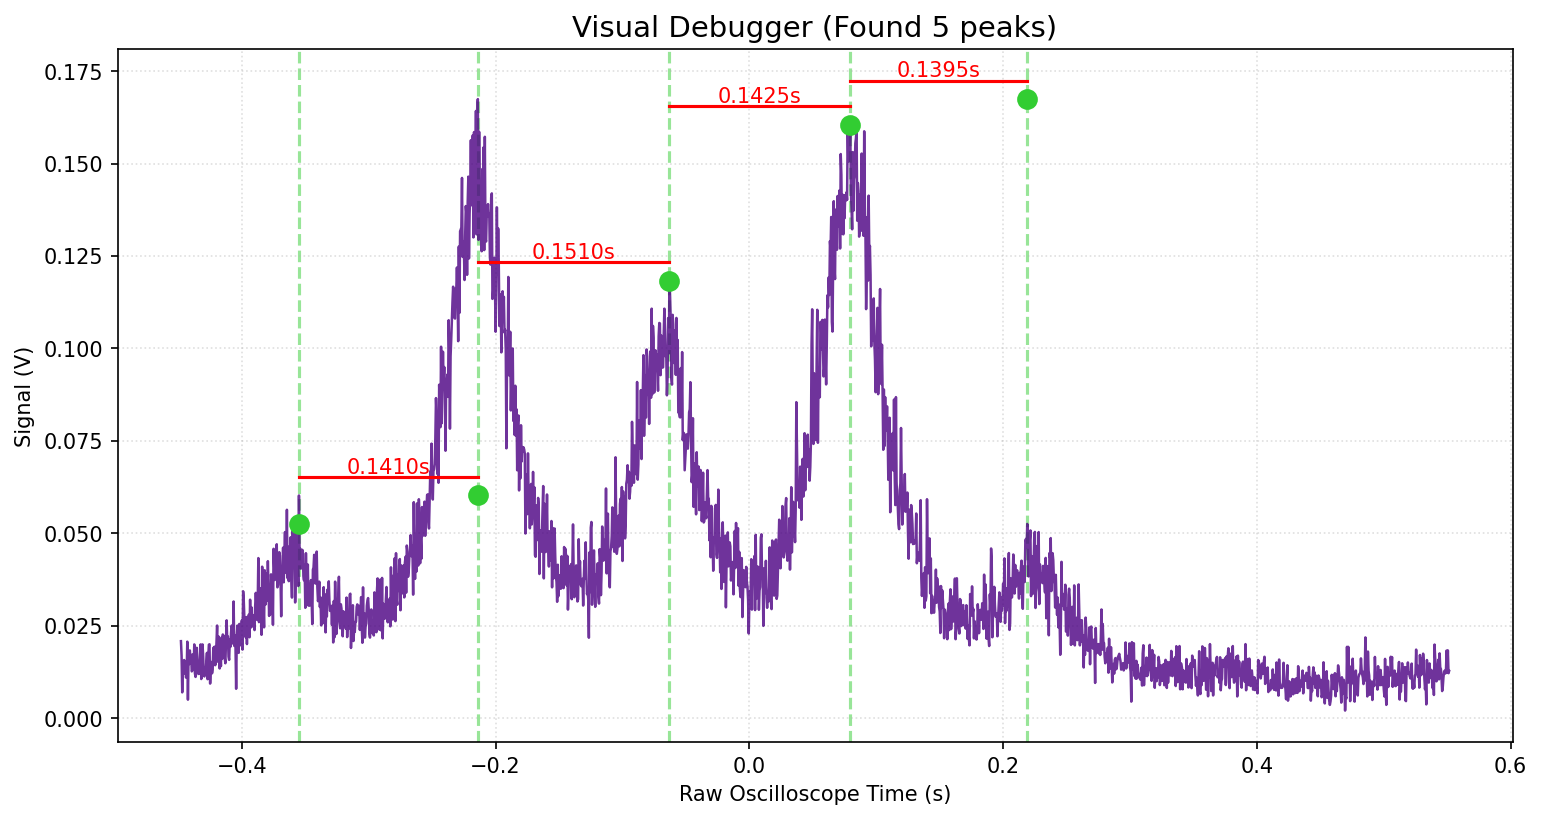

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from pathlib import Path

# --- 1. LOAD DATA ---
data_dir = Path("/Users/michelangelodondi/Documents/Research/rb6s-spectroscopy/data/01_raw/power_eom")
f = data_dir / "4121nm_eom_after1.csv"
df = pd.read_csv(f, skiprows=2, header=None)
df.columns = ['time_s', 'signal_v']
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# --- 2. TWEAK THESE TWO NUMBERS ---
# Prominence: How far a peak must rise above its local background.
# Distance: Minimum number of data points (not seconds!) between peaks.
TEST_PROMINENCE = 0.03 
TEST_DISTANCE = 150   

peaks, _ = find_peaks(df['signal_v'], prominence=TEST_PROMINENCE, distance=TEST_DISTANCE)

t_peaks = np.sort(df['time_s'].iloc[peaks].values)
v_peaks = np.sort(df['signal_v'].iloc[peaks].values)

# --- 3. PLOT AND MEASURE ---
plt.figure(figsize=(12, 6), dpi=150)
plt.plot(df['time_s'], df['signal_v'], color='indigo', linewidth=1.2, alpha=0.8)

# --- NEW: Vertical lines dropping from the green dots ---
for t in t_peaks:
    plt.axvline(x=t, color='limegreen', linestyle='--', alpha=0.5, zorder=1)

# Plot the green dots on top
plt.scatter(t_peaks, v_peaks, color='limegreen', s=80, zorder=5)

# Draw lines and text showing the exact gap between peaks
for i in range(len(t_peaks) - 1):
    t1, t2 = t_peaks[i], t_peaks[i+1]
    v_mid = max(v_peaks[i], v_peaks[i+1]) + 0.005 # Put text slightly above
    gap = t2 - t1
    
    # Draw a horizontal line connecting the peaks
    plt.plot([t1, t2], [v_mid, v_mid], color='red', linewidth=1.5)
    # Write the time gap above the line
    plt.text((t1 + t2) / 2, v_mid + 0.001, f"{gap:.4f}s", ha='center', color='red', fontsize=10)

plt.title(f"Visual Debugger (Found {len(t_peaks)} peaks)", fontsize=14)
plt.xlabel("Raw Oscilloscope Time (s)")
plt.ylabel("Signal (V)")
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pathlib import Path

# Import your custom loader (adjust path if needed depending on how your notebook is launched)
import sys
sys.path.append('../src')
from config_loader import load_config

# --- 1. LOAD CONFIGURATION ---
config = load_config()
rf_freq = config['eom_calibration']['rf_frequency_mhz']
prom_thresh = config['eom_calibration']['peak_finding']['prominence']
dist_thresh = config['eom_calibration']['peak_finding']['distance']
expected_peaks = config['eom_calibration']['peak_finding']['expected_peaks']

print(f"Loaded config: {rf_freq} MHz RF, Prominence={prom_thresh}, Distance={dist_thresh}")

# --- 2. LOAD DATA ---
data_dir = Path("../data/01_raw/power_eom")
f = data_dir / "4121nm_eom_after1.csv"
df = pd.read_csv(f, skiprows=2, header=None)
df.columns = ['time_s', 'signal_v']
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# --- 3. PEAK DETECTION ---
peaks, _ = find_peaks(df['signal_v'], prominence=prom_thresh, distance=dist_thresh)
t_peaks = np.sort(df['time_s'].iloc[peaks].values)

if len(t_peaks) == expected_peaks:
    print("✅ Found exact number of expected peaks.")
else:
    print(f"⚠️ Warning: Found {len(t_peaks)} peaks, but config expects {expected_peaks}.")